# HumanForYou — Exploration des données (EDA)

**Objectif :** Comprendre la structure des données, identifier les problèmes de qualité (valeurs manquantes, colonnes inutiles, déséquilibre des classes) et poser les bases du preprocessing.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RAW = '../data/raw/'

---
## 1. Chargement des données

In [2]:
general  = pd.read_csv(RAW + 'general_data.csv')
survey   = pd.read_csv(RAW + 'employee_survey_data.csv')
in_time  = pd.read_csv(RAW + 'in_time.csv', index_col=0)
out_time = pd.read_csv(RAW + 'out_time.csv', index_col=0)

print(f"general_data  : {general.shape}")
print(f"survey_data   : {survey.shape}")
print(f"in_time       : {in_time.shape}")
print(f"out_time      : {out_time.shape}")

general_data  : (4410, 24)
survey_data   : (4410, 4)
in_time       : (4410, 261)
out_time      : (4410, 261)


---
## 2. Aperçu général

In [3]:
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [4]:
general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [5]:
general.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,4410.0,NaN,NaN,NaN,36.92381,9.133301,18.0,30.0,36.0,43.0,60.0
Attrition,4410,2,No,3699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,4410,3,Travel_Rarely,3129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,4410,3,Research & Development,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,4410.0,NaN,NaN,NaN,9.192517,8.105026,1.0,2.0,7.0,14.0,29.0
Education,4410.0,NaN,NaN,NaN,2.912925,1.023933,1.0,2.0,3.0,4.0,5.0
EducationField,4410,6,Life Sciences,1818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,4410.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeID,4410.0,NaN,NaN,NaN,2205.5,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0
Gender,4410,2,Male,2646,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Variable cible : Attrition

C'est la colonne qu'on cherche à prédire. On vérifie si les classes sont équilibrées.

In [6]:
attr_counts = general['Attrition'].value_counts()
attr_pct    = general['Attrition'].value_counts(normalize=True) * 100

print(attr_counts)
print()
print(attr_pct.round(1).astype(str) + ' %')

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Attrition
No     83.9 %
Yes    16.1 %
Name: proportion, dtype: object


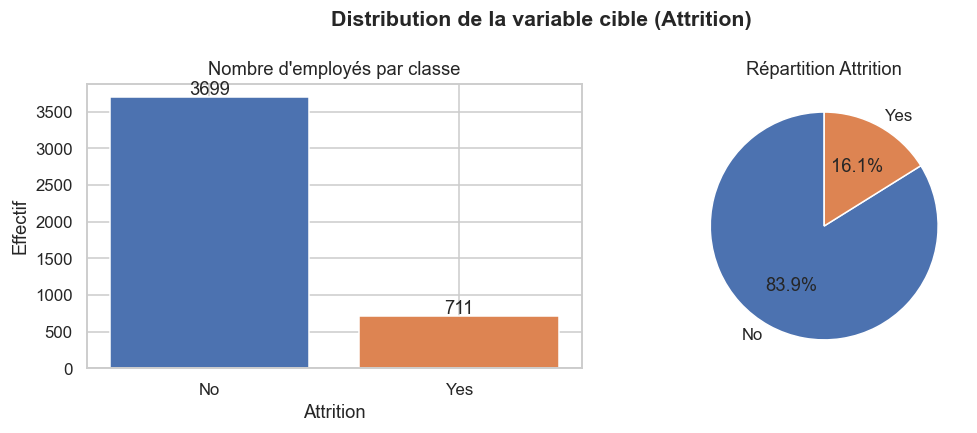


=> Déséquilibre : 83.9% Non / 16.1% Oui
=> Ce déséquilibre devra être pris en compte lors de la modélisation (SMOTE ou class_weight).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Barplot
axes[0].bar(attr_counts.index, attr_counts.values, color=['#4C72B0', '#DD8452'])
for i, (label, val) in enumerate(zip(attr_counts.index, attr_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=12)
axes[0].set_title('Nombre d\'employés par classe')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Effectif')

# Camembert
axes[1].pie(attr_counts.values, labels=attr_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Répartition Attrition')

plt.suptitle('Distribution de la variable cible (Attrition)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/attrition_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n=> Déséquilibre : {attr_pct['No']:.1f}% Non / {attr_pct['Yes']:.1f}% Oui")
print("=> Ce déséquilibre devra être pris en compte lors de la modélisation (SMOTE ou class_weight).")

---
## 4. Identification des colonnes inutiles

Certaines colonnes avec une seule valeur unique n'apportent aucune information.

In [8]:
nunique = general.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print("Colonnes constantes (1 seule valeur unique) :", constant_cols)

for col in constant_cols:
    print(f"  {col} → {general[col].unique()}")

Colonnes constantes (1 seule valeur unique) : ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount → [1]
  Over18 → ['Y']
  StandardHours → [8]


> **Décision** : `EmployeeCount`, `Over18` et `StandardHours` ont une seule valeur pour tous les employés → elles seront supprimées lors du preprocessing.

---
## 5. Valeurs manquantes

In [9]:
def missing_summary(df, name):
    na = df.isna().sum()
    na = na[na > 0]
    if na.empty:
        print(f"{name} : aucune valeur manquante")
    else:
        pct = (na / len(df) * 100).round(2)
        print(f"\n{name} — valeurs manquantes :")
        for col in na.index:
            print(f"  {col:35s} {na[col]:4d} ({pct[col]:.2f}%)")

missing_summary(general, 'general_data')
missing_summary(survey,  'employee_survey')


general_data — valeurs manquantes :
  NumCompaniesWorked                    19 (0.43%)
  TotalWorkingYears                      9 (0.20%)

employee_survey — valeurs manquantes :
  EnvironmentSatisfaction               25 (0.57%)
  JobSatisfaction                       20 (0.45%)
  WorkLifeBalance                       38 (0.86%)


> **Décision** : Les NA dans `general_data` (`NumCompaniesWorked` et `TotalWorkingYears`) représentent < 0.5% des données → **imputation par la médiane** (robuste aux valeurs extrêmes).
>
> Les NA dans `employee_survey` (satisfaction environnement/travail/équilibre) représentent < 1% → **imputation par la médiane** également. Ces réponses manquantes correspondent à des employés qui n'ont pas répondu à l'enquête : on ne les supprime pas pour ne pas introduire de biais (les non-répondants pourraient être justement les moins satisfaits).

---
## 6. Distribution des variables numériques

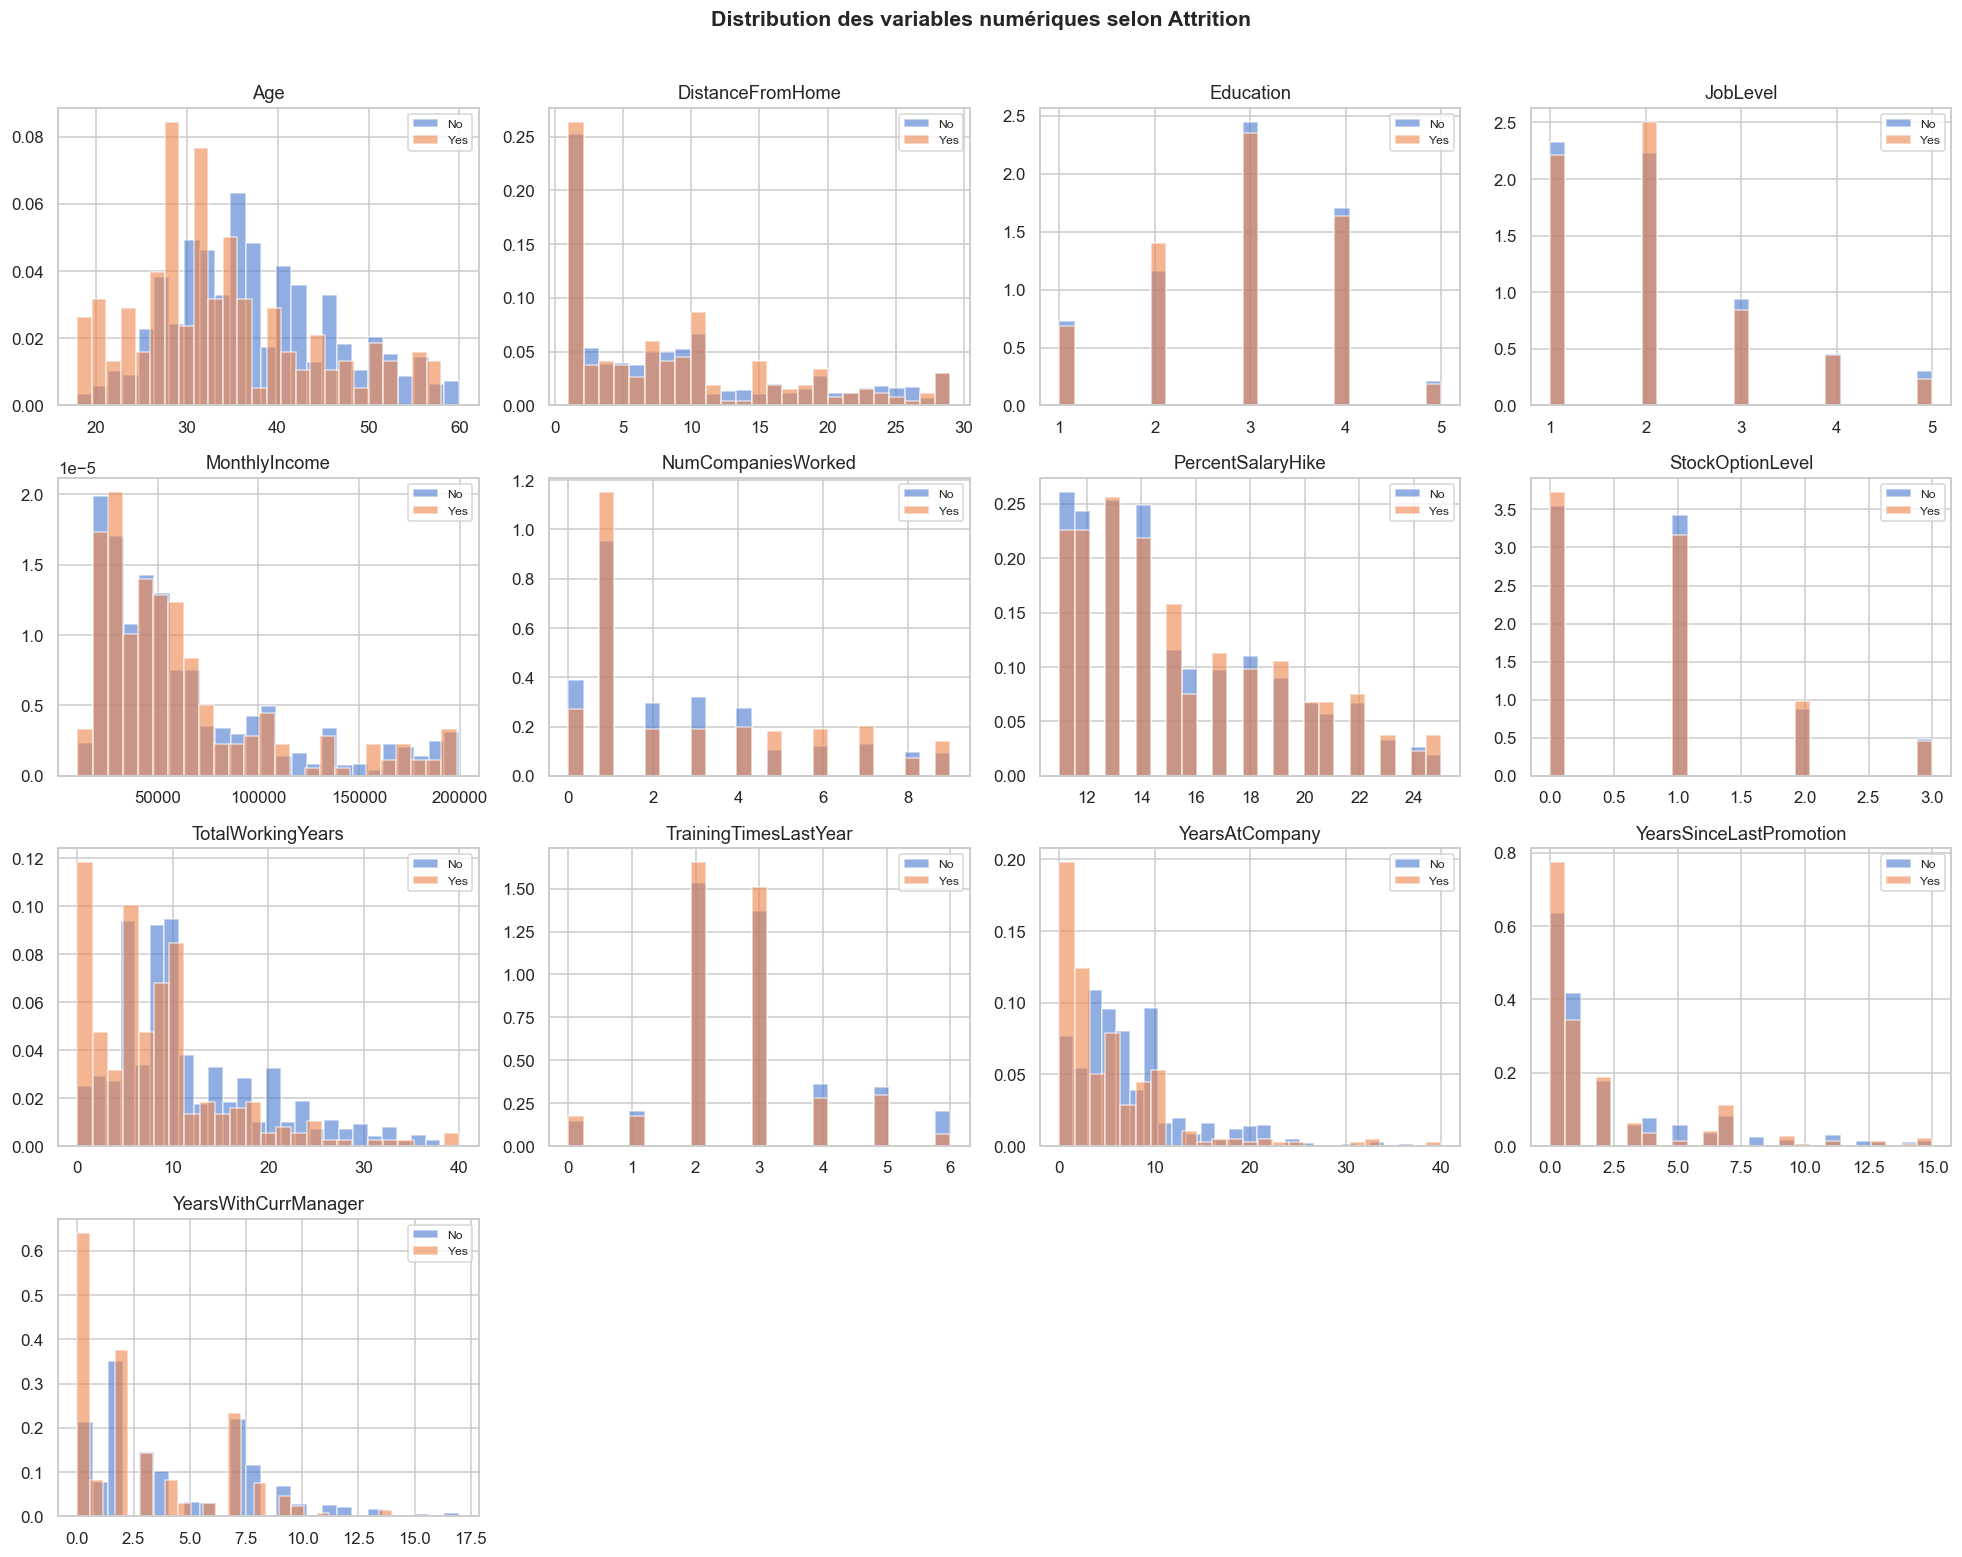

In [10]:
num_cols = general.select_dtypes(include='number').columns.drop(['EmployeeID', 'EmployeeCount', 'StandardHours'])

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in general.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=25, alpha=0.6, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des variables numériques selon Attrition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/numeric_distributions.png', bbox_inches='tight')
plt.show()

---
## 7. Distribution des variables catégorielles

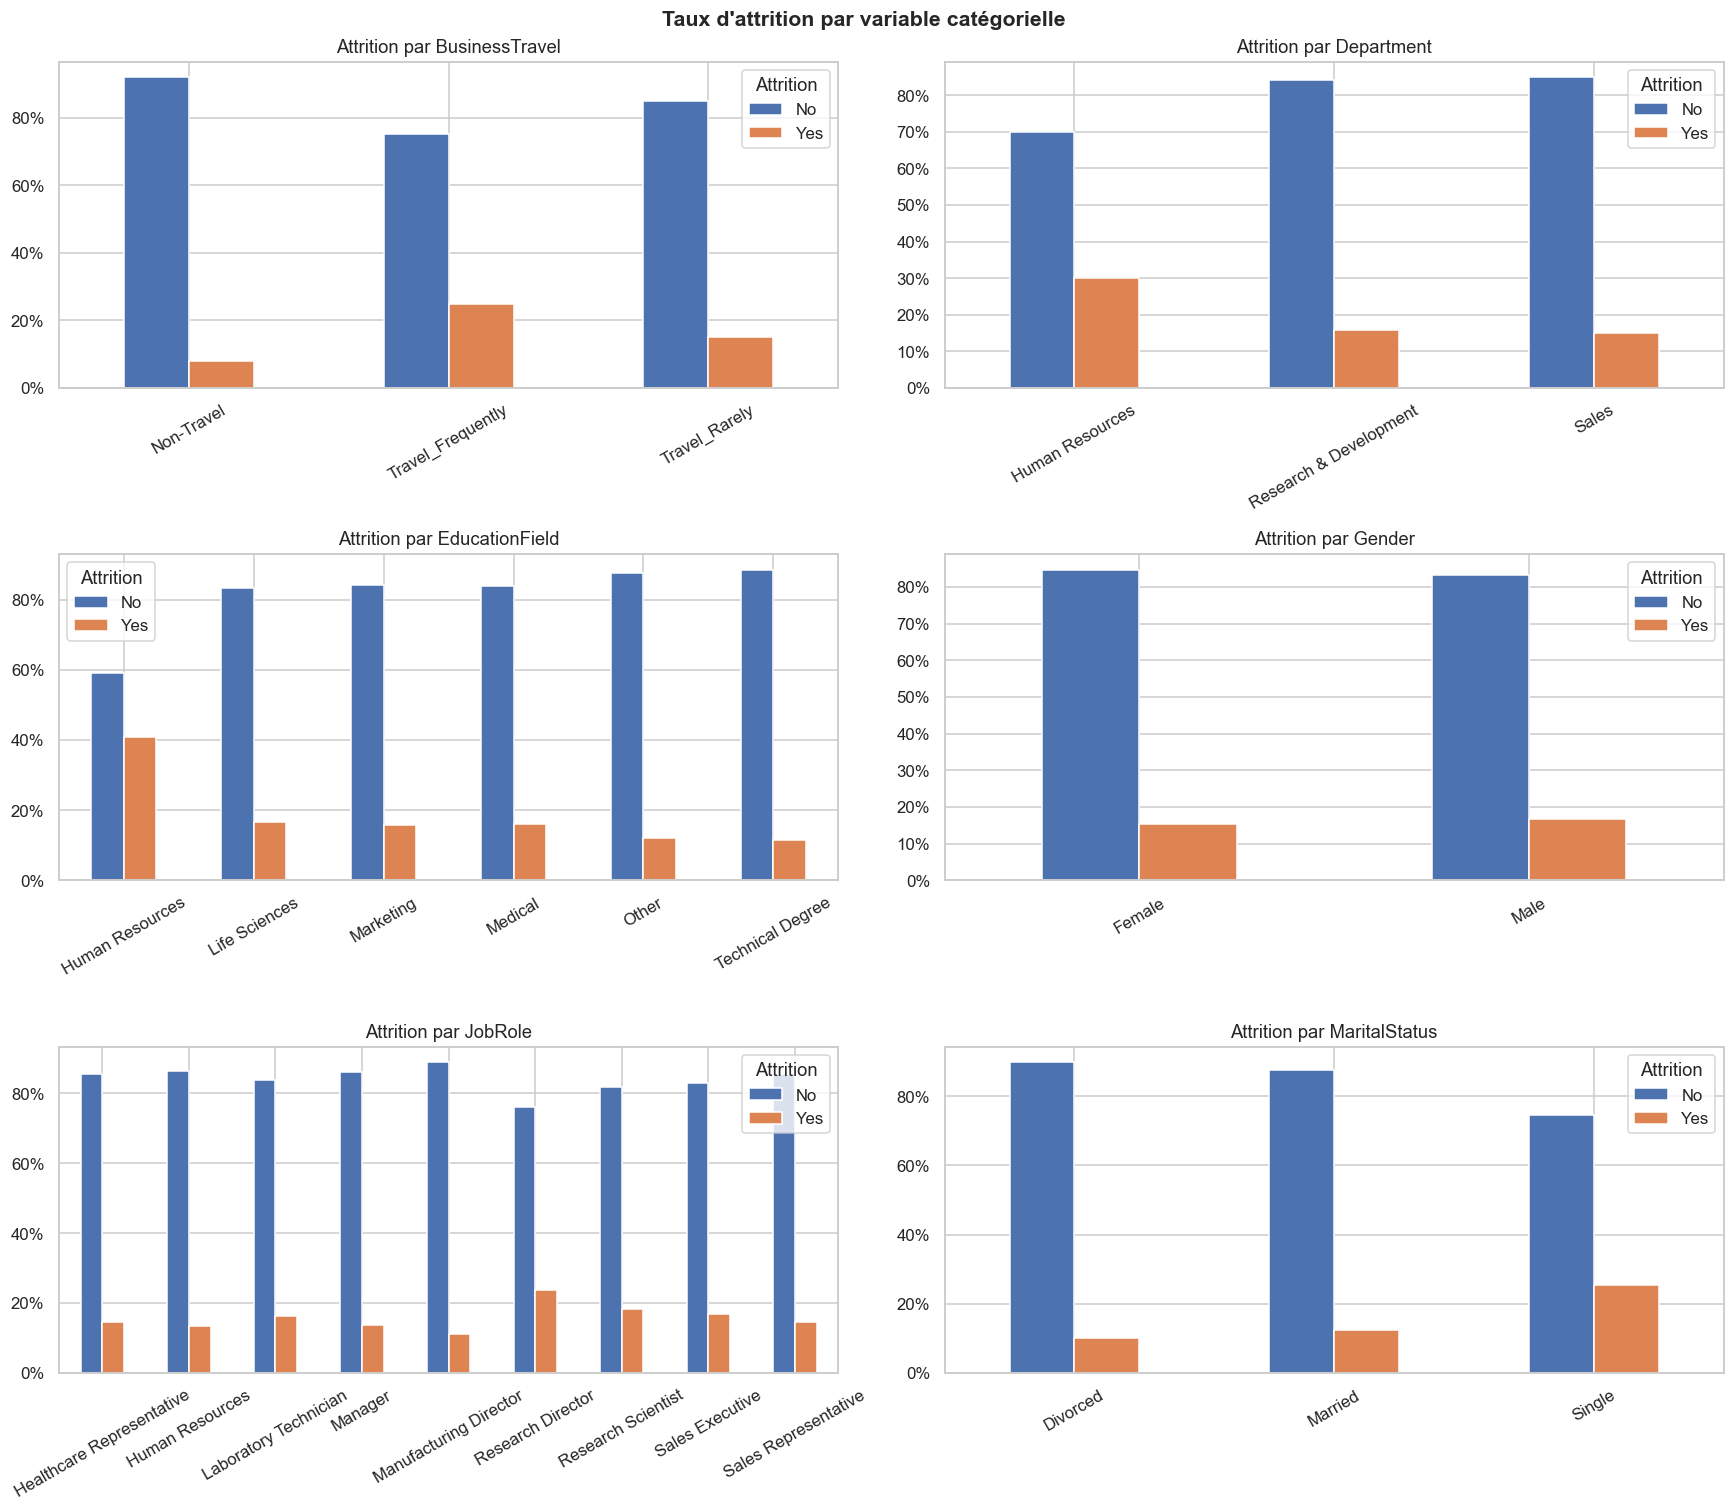

In [11]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    tbl = general.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition')

plt.suptitle('Taux d\'attrition par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/categorical_attrition.png', bbox_inches='tight')
plt.show()

---
## 8. Analyse des scores de satisfaction (enquête employés)

In [12]:
survey.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


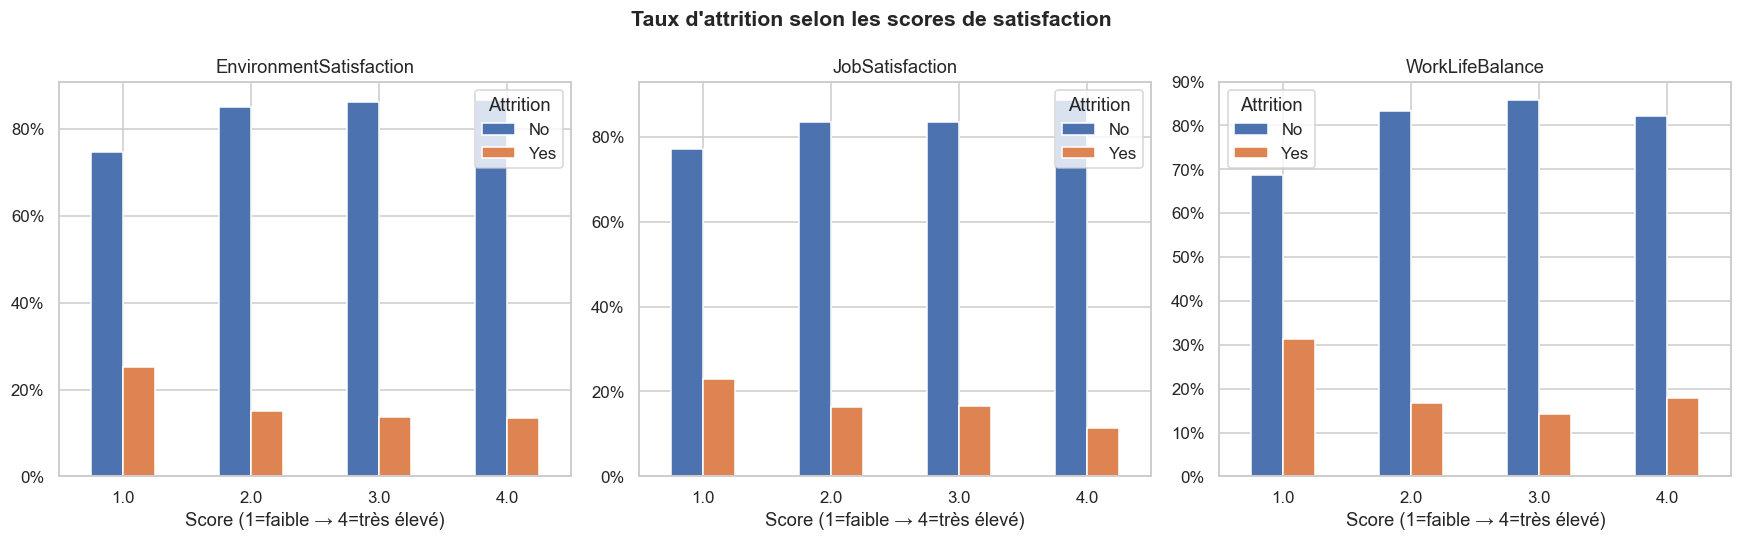

In [13]:
# Fusionner survey avec Attrition
survey_merged = survey.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(sat_cols):
    tbl = survey_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')
    axes[i].set_xlabel('Score (1=faible → 4=très élevé)')

plt.suptitle('Taux d\'attrition selon les scores de satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/satisfaction_attrition.png', bbox_inches='tight')
plt.show()

---
## 9. Matrice de corrélation (variables numériques)

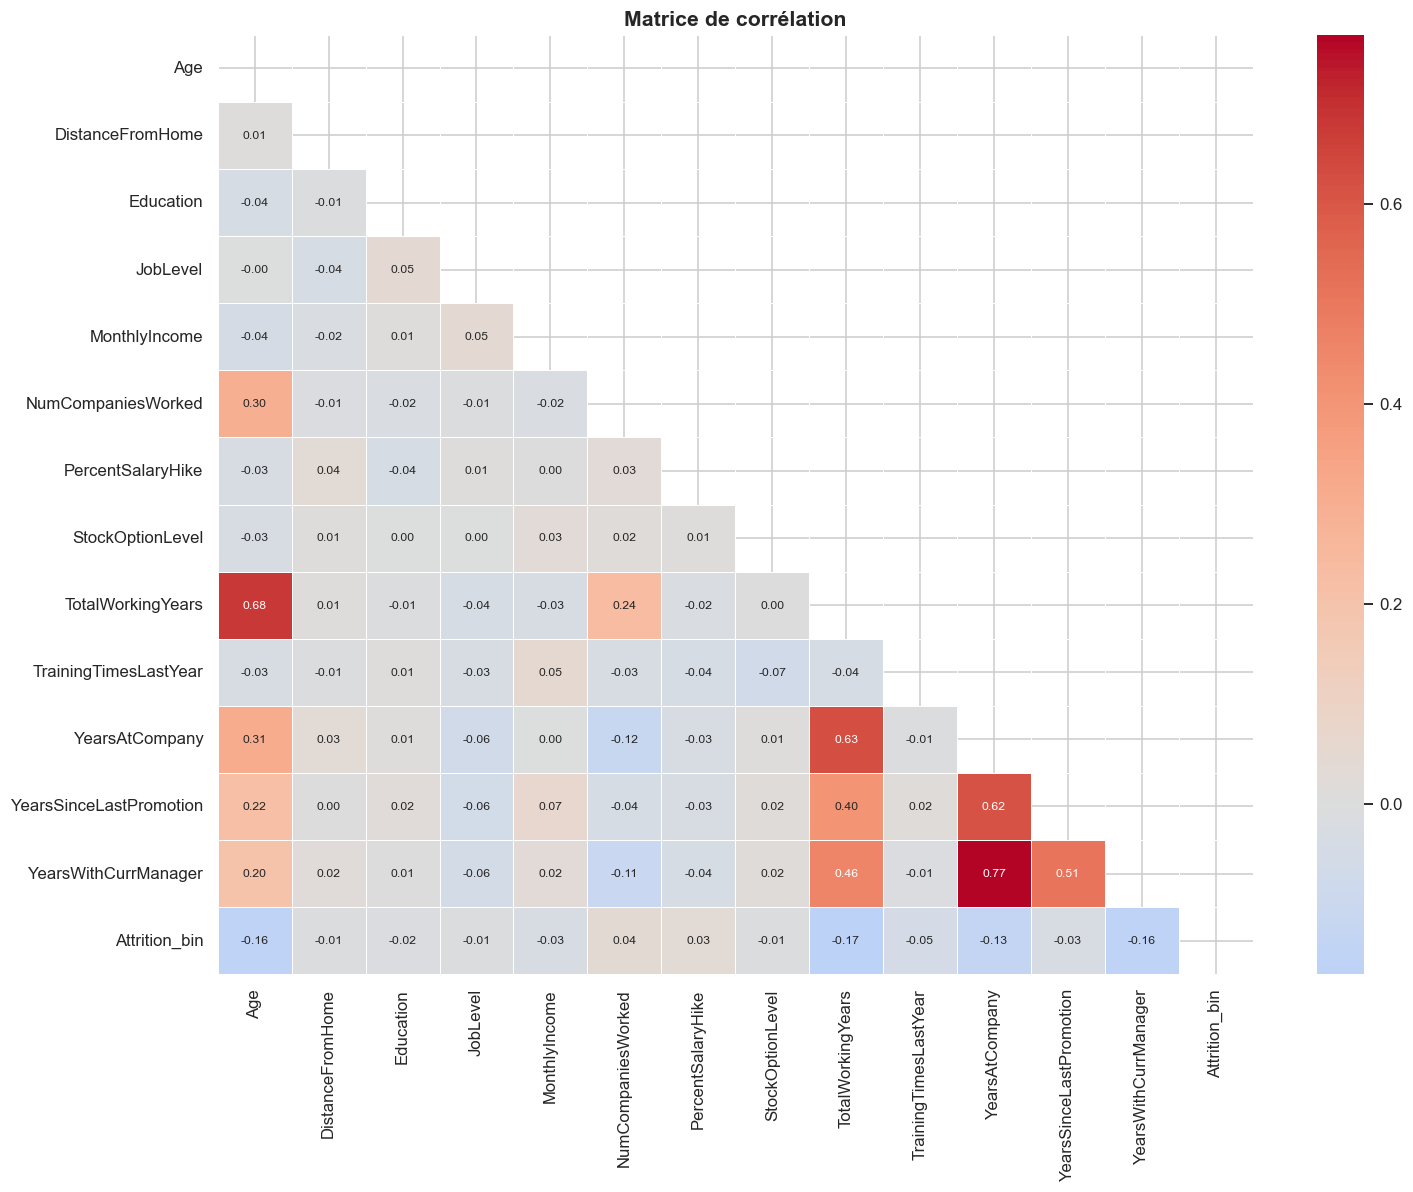

In [14]:
# Ajouter Attrition encodée pour la corrélation
gen_corr = general.copy()
gen_corr['Attrition_bin'] = (gen_corr['Attrition'] == 'Yes').astype(int)

num_corr_cols = list(num_cols) + ['Attrition_bin']
corr_matrix = gen_corr[num_corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [15]:
# Top corrélations avec Attrition
corr_with_target = corr_matrix['Attrition_bin'].drop('Attrition_bin').sort_values(key=abs, ascending=False)
print("Corrélations avec Attrition (triées par valeur absolue) :")
print(corr_with_target.round(3).to_string())

Corrélations avec Attrition (triées par valeur absolue) :
TotalWorkingYears         -0.170
Age                       -0.159
YearsWithCurrManager      -0.156
YearsAtCompany            -0.134
TrainingTimesLastYear     -0.049
NumCompaniesWorked         0.042
YearsSinceLastPromotion   -0.033
PercentSalaryHike          0.033
MonthlyIncome             -0.031
Education                 -0.015
JobLevel                  -0.010
DistanceFromHome          -0.010
StockOptionLevel          -0.007


---
## 10. Exploration des données de badgeage (in_time / out_time)

On extrait des statistiques synthétiques à partir des 261 colonnes de dates.

In [16]:
# Convertir toutes les colonnes en datetime
in_dt  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt = out_time.apply(pd.to_datetime, errors='coerce')

# Durée de travail par jour en heures
work_hours = (out_dt - in_dt).apply(lambda s: s.dt.total_seconds() / 3600)

# Features synthétiques par employé
badge_features = pd.DataFrame(index=in_time.index)
badge_features['avg_hours_per_day']   = work_hours.mean(axis=1)
badge_features['std_hours_per_day']   = work_hours.std(axis=1)         # variabilité horaires
badge_features['days_absent']         = work_hours.isna().sum(axis=1)  # jours sans badge
badge_features['days_overtime_8h']    = (work_hours > 8).sum(axis=1)   # jours > 8h
badge_features['avg_arrival_hour']    = in_dt.apply(
    lambda col: col.dt.hour + col.dt.minute / 60, axis=0).mean(axis=1)

badge_features.index.name = 'EmployeeID'
badge_features = badge_features.reset_index()
# L'index correspond aux lignes (1-based EmployeeID selon la première colonne du CSV)
badge_features['EmployeeID'] = general['EmployeeID'].values

print(badge_features.describe().round(2))

       EmployeeID  avg_hours_per_day  std_hours_per_day  days_absent  \
count     4410.00            4410.00            4410.00      4410.00   
mean      2205.50               7.70               0.30        24.73   
std       1273.20               1.34               0.01         5.50   
min          1.00               5.95               0.25        13.00   
25%       1103.25               6.67               0.29        20.00   
50%       2205.50               7.41               0.30        25.00   
75%       3307.75               8.37               0.31        29.00   
max       4410.00              11.03               0.34        36.00   

       days_overtime_8h  avg_arrival_hour  
count           4410.00           4410.00  
mean              76.15              9.99  
std              100.02              0.02  
min                0.00              9.93  
25%                0.00              9.98  
50%                6.00              9.99  
75%              205.00             10.00  

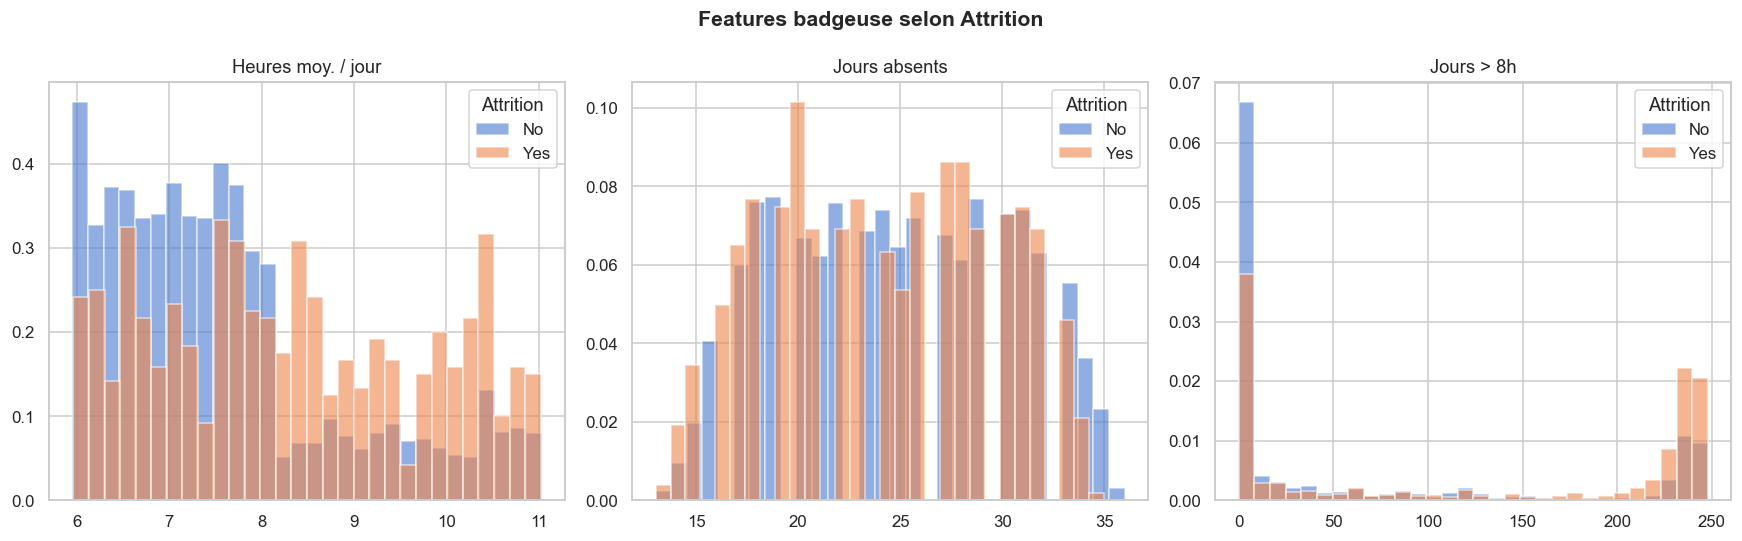

In [17]:
# Lien entre features de badgeage et attrition
badge_merged = badge_features.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
feat_badge = ['avg_hours_per_day', 'days_absent', 'days_overtime_8h']
labels_badge = ['Heures moy. / jour', 'Jours absents', 'Jours > 8h']

for i, (col, label) in enumerate(zip(feat_badge, labels_badge)):
    for attrition, grp in badge_merged.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=30, alpha=0.6, label=attrition, density=True)
    axes[i].set_title(label)
    axes[i].legend(title='Attrition')

plt.suptitle('Features badgeuse selon Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/badge_features_attrition.png', bbox_inches='tight')
plt.show()

---
## 11. Résumé des décisions issues de l'EDA

| # | Sujet | Décision |
|---|-------|----------|
| 1 | Colonnes constantes | Supprimer `EmployeeCount`, `Over18`, `StandardHours` |
| 2 | Valeurs manquantes numériques | Imputation par la **médiane** |
| 3 | Valeurs manquantes survey | Imputation par la **médiane** (non-répondants conservés) |
| 4 | Déséquilibre des classes | 84% / 16% → gérer avec **SMOTE** ou `class_weight='balanced'` |
| 5 | Features badgeuse | Extraire : heures moy/jour, variabilité, jours absents, jours > 8h, heure d'arrivée moy. |
| 6 | Encodage catégoriel | `LabelEncoder` ou `OneHotEncoder` selon le modèle |

**Prochaine étape : preprocessing et feature engineering → notebook 02**